In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importing Dataset

In [6]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [86]:
df.head()

,customer_id,age,gender,item_purchased,category,purchased_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adults,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adults,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [8]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [9]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

Filling Missing Values

In [10]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Changing column name in proper format (ie in snake_case)

In [12]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns= {'purchase_amount_(usd)' : 'purchased_amount'})

In [13]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchased_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

Creating a new column "age_group"

In [14]:
labels = ['Young Adults' , 'Adult' , 'Middle-aged' , 'Senior']
df['age_group'] = pd.qcut(df['age'] , q=4 , labels = labels)

In [15]:
df[['age_group', 'age']].head(10)

,age_group,age
0,Middle-aged,55
1,Young Adults,19
2,Middle-aged,50
3,Young Adults,21
4,Middle-aged,45
5,Middle-aged,46
6,Senior,63
7,Young Adults,27
8,Young Adults,26
9,Middle-aged,57


In [20]:
df.head(10)

,customer_id,age,gender,item_purchased,category,purchased_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle-aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adults
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adults
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-aged
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly,Middle-aged
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly,Senior
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly,Young Adults
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually,Young Adults
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly,Middle-aged


In [19]:
age_analysis =df.groupby('age_group')['purchased_amount'].sum().sort_values(ascending=False)
print(age_analysis)

age_group
Young Adults    62143
Middle-aged     59197
Adult           55978
Senior          55763
Name: purchased_amount, dtype: int64


Creating column "purchase_frequency_days"

In [21]:
df['frequency_of_purchases'].unique()

<StringArray>
[   'Fortnightly',         'Weekly',       'Annually',      'Quarterly',
      'Bi-Weekly',        'Monthly', 'Every 3 Months']
Length: 7, dtype: str

In [23]:
# Creating col "purchase_frequency_days"

frequency_mapping = {
    'Fortnightly' : 14,
    'Weekly' : 7,
    'Monthly' : 30,
    'Quarterly' : 90,
    'Bi-Weekly' : 14,
    'Annually' : 365,
    'Every 3 Months' : 90

}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [24]:
df[['frequency_of_purchases' , 'purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [25]:
df[['discount_applied' , 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [26]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [27]:
# drop 'promo_code_used' column

df = df.drop('promo_code_used' , axis=1)

In [28]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchased_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

Revenue KPIs

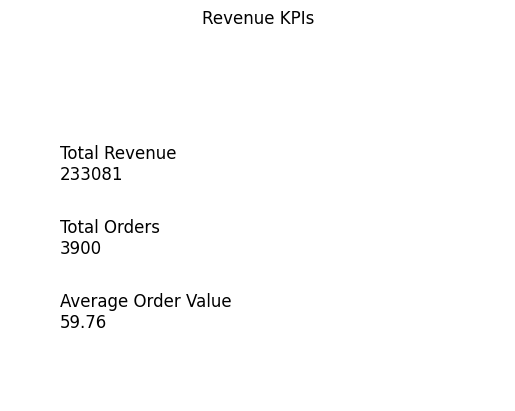

In [73]:
total_revenue = df['purchased_amount'].sum()
total_orders = df.shape[0]
average_order_value = df['purchased_amount'].mean().round(2)

import matplotlib.pyplot as plt

plt.figure()

plt.text(0.1, 0.6, f"Total Revenue\n{total_revenue}", fontsize=12)
plt.text(0.1, 0.4, f"Total Orders\n{total_orders}", fontsize=12)
plt.text(0.1, 0.2, f"Average Order Value\n{round(average_order_value,2)}", fontsize=12)

plt.axis('off')
plt.title("Revenue KPIs")

plt.show()

Revenue by Category

In [35]:
revenue_category = df.groupby('category')['purchased_amount'].sum().reset_index().sort_values(by='purchased_amount', ascending=False)
revenue_category

,category,purchased_amount
1,Clothing,104264
0,Accessories,74200
2,Footwear,36093
3,Outerwear,18524


Revenue by Customer Segmentation ( "age_group" )

In [37]:
age_analysis = df.groupby('age_group')['purchased_amount'].sum().reset_index().sort_values(by='purchased_amount', ascending=False)
age_analysis

,age_group,purchased_amount
0,Young Adults,62143
2,Middle-aged,59197
1,Adult,55978
3,Senior,55763


Top Customers

In [47]:
top_customers = df.groupby('customer_id')['purchased_amount'].sum().reset_index().sort_values(by='purchased_amount',ascending=False).head(5)
top_customers

,customer_id,purchased_amount
1479,1480,100
1456,1457,100
1591,1592,100
2071,2072,100
1421,1422,100


Payment Method Analysis

In [50]:
pay_method = df.groupby('payment_method')['purchased_amount'].sum().reset_index().sort_values(by='purchased_amount',ascending=False).head(10)
pay_method

,payment_method,purchased_amount
2,Credit Card,40310
4,PayPal,40109
1,Cash,40002
3,Debit Card,38742
5,Venmo,37374
0,Bank Transfer,36544


Rating Vs Spending Analysis

Text(0, 0.5, 'Purchased_Amount')

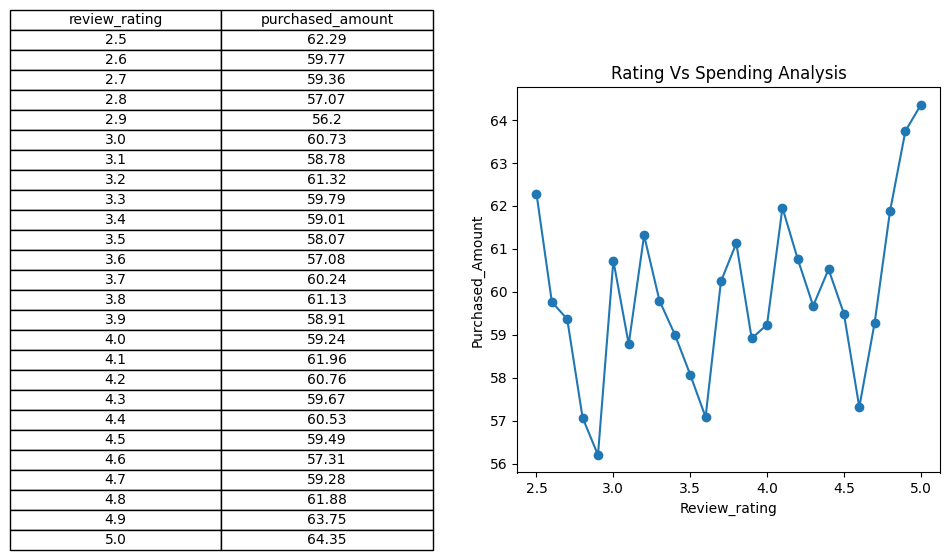

In [71]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT SIDE: The Table ---
ax[0].axis('off')  # Hide the axes for the table side
tbl = ax[0].table(cellText=rating_analysis.values.round(2),
                  colLabels=rating_analysis.columns,
                  loc='center',
                  cellLoc='center')
tbl.scale(1, 1.2)  # Adjust scaling to make it readable
#ax[0].set_title("Rating Analysis Data")

# --- RIGHT SIDE: The Line Plot ---
ax[1].plot(rating_analysis['review_rating'], rating_analysis['purchased_amount'], marker='o')
ax[1].set_title("Rating Vs Spending Analysis")
ax[1].set_xlabel("Review_rating")
ax[1].set_ylabel("Purchased_Amount")

Connecting MySql to Python

In [ ]:
!pip install pymysql sqlalchemy

In [84]:
# import library
from sqlalchemy import create_engine

#MySql Connection Deatails
user = "root"
password = "Rizwan214039"
host = "localhost"
port = "3306"
database = "customer_analysis"

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

# Load DataFrame into MySql
table_name = "customers"
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}' .")

Data successfully loaded into table 'customers' in database 'customer_analysis' .
